<a href="https://colab.research.google.com/github/Patro331/blood-smear-sickle-cell-classification/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Smear Sickle Cell Classification
## MSB7215: Machine Learning in Biomedicine
### Notebook 01: Data Understanding

**Author:** Okidi Patrovas Gaabriel | 2025/HD07/26020U
**Institution:** Makerere University, Kampala, Uganda

## Overview

This notebook provides a thorough understanding of the dataset used
for sickle cell disease detection from peripheral blood smear images.
Following ML in Biomedicine framework, we examine
the dataset structure, class distribution, image characteristics,
and data quality before any feature extraction or modelling.

The dataset combines two sources:
1. Tushabe et al. (2024) — Ugandan clinical mobile-phone microscopy images
2. BCCD Dataset (Shenggan et al.) — normal peripheral blood smear images

Combined total: 933 images across two classes (positive and negative)
Task: Binary classification — sickle cell positive vs normal

In [1]:
# Install and import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully")

All libraries imported successfully


## 1. Mount Google Drive and Define Data Paths

We mount Google Drive to access the dataset. The images are organised
into two folders — positive (sickle cell) and negative (normal) —
consistent with the binary classification task.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Define paths — reusing the same processed data from the deep learning project
BASE_DIR      = '/content/drive/MyDrive/sickle-cell-detection'
POSITIVE_DIR  = f'{BASE_DIR}/data/raw/positive'
NEGATIVE_DIR  = f'{BASE_DIR}/data/raw/negative'

# Verify paths exist
print(f"Positive folder exists: {os.path.exists(POSITIVE_DIR)}")
print(f"Negative folder exists: {os.path.exists(NEGATIVE_DIR)}")

# Count images
pos_images = [f for f in os.listdir(POSITIVE_DIR)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
neg_images = [f for f in os.listdir(NEGATIVE_DIR)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"\nPositive images: {len(pos_images)}")
print(f"Negative images: {len(neg_images)}")
print(f"Total images:    {len(pos_images) + len(neg_images)}")

Mounted at /content/drive
Positive folder exists: True
Negative folder exists: True

Positive images: 422
Negative images: 511
Total images:    933


## 2. Understanding the Dataset Variables

Following standard ML practice, we first understand what each
variable in our dataset represents before any processing.

This dataset differs from typical tabular medical datasets in that
the raw input is image data. Each image represents one observation
(one blood smear sample) and the target variable is the class label.

| Variable | Type | Description |
|---|---|---|
| Image | Input feature | RGB microscopy image of a peripheral blood smear |
| Class label | Target variable | Binary — 1 (positive, sickle cell) or 0 (negative, normal) |
| Image source | Metadata | Tushabe (2024) Uganda or BCCD Dataset |
| Image size | Metadata | Width x Height in pixels — varies across samples |
| Colour mode | Metadata | RGB — three channels (Red, Green, Blue) |

The target variable is what we are trying to predict. The input
features will be extracted from the raw images in the next notebook
using HOG (Histogram of Oriented Gradients) feature extraction.

In [3]:
# Build a metadata dataframe — one row per image
# This gives us a tabular view of our dataset that framework expects

records = []

for img_name in pos_images:
    img_path = os.path.join(POSITIVE_DIR, img_name)
    img      = Image.open(img_path)
    w, h     = img.size
    records.append({
        'filename':  img_name,
        'class':     'positive',
        'label':     1,
        'width':     w,
        'height':    h,
        'mode':      img.mode,
        'source':    'Tushabe (2024) Uganda',
        'aspect_ratio': round(w / h, 2)
    })

for img_name in neg_images:
    img_path = os.path.join(NEGATIVE_DIR, img_name)
    img      = Image.open(img_path)
    w, h     = img.size
    source   = 'Tushabe (2024) Uganda' if 'BloodImage' not in img_name \
                else 'BCCD Dataset'
    records.append({
        'filename':  img_name,
        'class':     'negative',
        'label':     0,
        'width':     w,
        'height':    h,
        'mode':      img.mode,
        'source':    source,
        'aspect_ratio': round(w / h, 2)
    })

df = pd.DataFrame(records)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (933, 8)

Column names: ['filename', 'class', 'label', 'width', 'height', 'mode', 'source', 'aspect_ratio']

First 5 rows:


,filename,class,label,width,height,mode,source,aspect_ratio
0,unlabelled_10.jpg,positive,1,3082,3094,RGB,Tushabe (2024) Uganda,1.00
1,unlabelled_111.jpg,positive,1,3253,3330,RGB,Tushabe (2024) Uganda,0.98
2,unlabelled_108.jpg,positive,1,3077,3190,RGB,Tushabe (2024) Uganda,0.96
3,unlabelled_115.jpg,positive,1,3306,3399,RGB,Tushabe (2024) Uganda,0.97
4,unlabelled_113.jpg,positive,1,3154,3184,RGB,Tushabe (2024) Uganda,0.99


### Observations

The dataset metadata dataframe contains 933 rows — one per image —
and 8 columns covering the filename, class label, image dimensions,
colour mode, data source, and aspect ratio.

All images are in RGB colour mode, confirming no grayscale or
corrupted colour space issues exist. The first five rows show
positive class images from the Tushabe (2024) Uganda dataset with
large dimensions around 3000x3000 pixels and near-square aspect
ratios close to 1.0, consistent with mobile phone microscope capture
where the circular field of view produces approximately square images.

## 3. Data Types and Structure

We inspect the data types of
each column and check for any structural issues before proceeding
to analysis. This is equivalent to the .info() check performed on
tabular medical datasets.

In [4]:
# Data types and structure — equivalent to .info() in tabular datasets
print("Dataset Info:")
print("=" * 50)
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

print(f"\nClass distribution:")
print(df['class'].value_counts())
print(f"\nSource distribution:")
print(df['source'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filename      933 non-null    object 
 1   class         933 non-null    object 
 2   label         933 non-null    int64  
 3   width         933 non-null    int64  
 4   height        933 non-null    int64  
 5   mode          933 non-null    object 
 6   source        933 non-null    object 
 7   aspect_ratio  933 non-null    float64
dtypes: float64(1), int64(3), object(4)
memory usage: 58.4+ KB

Data Types:
filename         object
class            object
label             int64
width             int64
height            int64
mode             object
source           object
aspect_ratio    float64
dtype: object

Unique values per column:
  filename: 933 unique values
  class: 2 unique values
  label: 2 unique values
  width: 123 unique values
  height: 233 unique values
  mode: 

### Observations

The dataset is clean and well structured with no missing values
across all 933 entries and 8 columns. All columns have their
expected data types — filenames and categorical variables are
stored as objects, image dimensions as integers, and aspect ratio
as a float.

Several key observations stand out. Every image has a unique
filename confirming no duplicates exist in the dataset. All 933
images share a single colour mode of RGB, requiring no colour
space conversion during preprocessing. The class column contains
exactly 2 unique values confirming the binary nature of the task.

The class distribution shows 511 negative images and 422 positive
images, a mild imbalance with the negative class being slightly
larger. This will need to be addressed during model training.

The source distribution confirms that 569 images originate from
the Tushabe (2024) Ugandan clinical dataset and 364 from the BCCD
Dataset, reflecting the two-source composition of the training
corpus.

## 4. Missing Value Analysis

A critical step in any ML pipeline is identifying and handling
missing values. The framework uses missingno to
visualise missingness patterns and SimpleImputer to handle them.
We apply this to our metadata dataframe to confirm data completeness
before feature extraction.

Missing Values Per Column:
              Missing Count  Missing Percentage
filename                  0                 0.0
class                     0                 0.0
label                     0                 0.0
width                     0                 0.0
height                    0                 0.0
mode                      0                 0.0
source                    0                 0.0
aspect_ratio              0                 0.0

Total missing values: 0


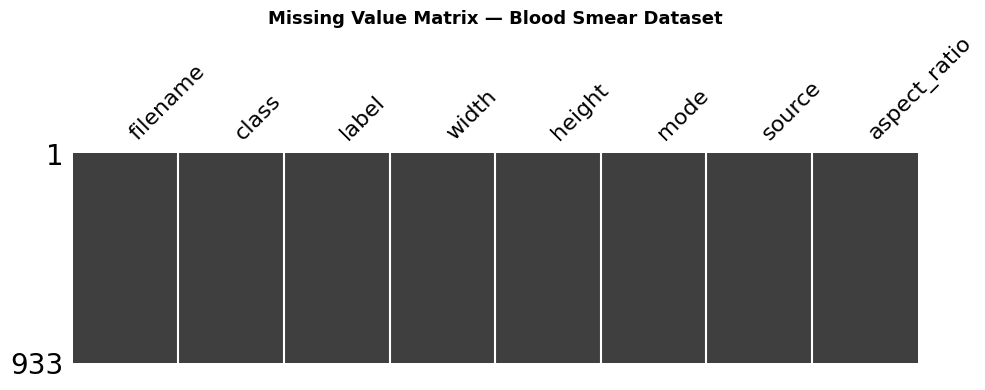

Figure saved


In [5]:
# Missing value analysis — following missingno approach
print("Missing Values Per Column:")
print("=" * 40)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})
print(missing_df)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Visualise missingness
fig, ax = plt.subplots(figsize=(10, 4))
msno.matrix(df, ax=ax, sparkline=False)
ax.set_title('Missing Value Matrix — Blood Smear Dataset',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/missing_values.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

### Observations

The missing value analysis confirms that the dataset is completely
clean with no missing values across any of the eight columns. The
missing value matrix shows a solid uninterrupted pattern across all
933 entries, visually confirming full data completeness.

This is an expected finding given that both source datasets were
curated and published in peer-reviewed research. The Tushabe (2024)
dataset was collected under controlled field conditions with
documented quality checks, and the BCCD dataset has been widely
used in published research with no known quality issues.

Since no missing values exist, imputation is not required for the
metadata features. However during HOG feature extraction in the
next notebook, we will verify that all images load correctly and
produce valid feature vectors.

## 5. Summary Statistics

We compute summary statistics for the numerical columns in the
metadata dataframe to understand the distribution of image
dimensions and aspect ratios across the dataset.

In [6]:
# Summary statistics for numerical columns
print("Summary Statistics:")
print("_" * 50)
print(df[['width', 'height', 'aspect_ratio', 'label']].describe().round(2))

# Summary statistics split by class
print("\nSummary Statistics by Class:")
print("_" * 50)
print(df.groupby('class')[['width', 'height', 'aspect_ratio']].describe().round(2))

Summary Statistics:
__________________________________________________
         width   height  aspect_ratio   label
count   933.00   933.00        933.00  933.00
mean   1152.95  1099.17          1.12    0.45
std     797.15   851.80          0.17    0.50
min     469.00   436.00          0.75    0.00
25%     640.00   480.00          0.99    0.00
50%    1000.00   992.00          1.01    0.00
75%    1000.00  1023.00          1.33    1.00
max    4160.00  3440.00          1.33    1.00

Summary Statistics by Class:
__________________________________________________
          width                                                           \
          count     mean     std    min     25%     50%      75%     max   
class                                                                      
negative  511.0   743.56  163.12  640.0   640.0   640.0  1000.00  1000.0   
positive  422.0  1648.68  961.64  469.0  1000.0  1000.0  2904.75  4160.0   

         height           ...                  aspect

### Observations

The summary statistics reveal important characteristics about the
dataset that directly inform the preprocessing decisions made in
subsequent notebooks.

Overall, image widths range from 469 to 4160 pixels with a mean
of 1152 pixels, and heights range from 436 to 3440 pixels with a
mean of 1099 pixels. The high standard deviations of 797 and 851
respectively confirm significant size variation across the dataset,
making resizing a mandatory preprocessing step before any feature
extraction.

The class-level breakdown is particularly revealing. Negative class
images are considerably smaller, with a mean width of 744 pixels
and mean height of 634 pixels, reflecting the controlled laboratory
conditions under which the BCCD dataset was captured. Positive class
images are substantially larger, with a mean width of 1649 pixels
and mean height of 1662 pixels, reflecting the higher resolution
of mobile phone cameras used in Ugandan clinical settings.

The aspect ratio analysis shows a clear difference between the two
classes. Positive images have a mean aspect ratio of 1.00 and very
low standard deviation of 0.05, confirming the near-square circular
microscope field of view characteristic of mobile phone microscopy.
Negative images have a higher mean aspect ratio of 1.23, reflecting
the rectangular format of laboratory camera captures from the BCCD
dataset.

This systematic difference in image dimensions between the two
classes represents a domain gap that must be addressed through
standardised resizing during feature extraction.

## 6. Class Distribution Visualisation

We visualise the class distribution to clearly communicate the
degree of class imbalance in the dataset. Class imbalance can
bias a classifier towards the majority class, producing inflated
accuracy while performing poorly on the minority class.

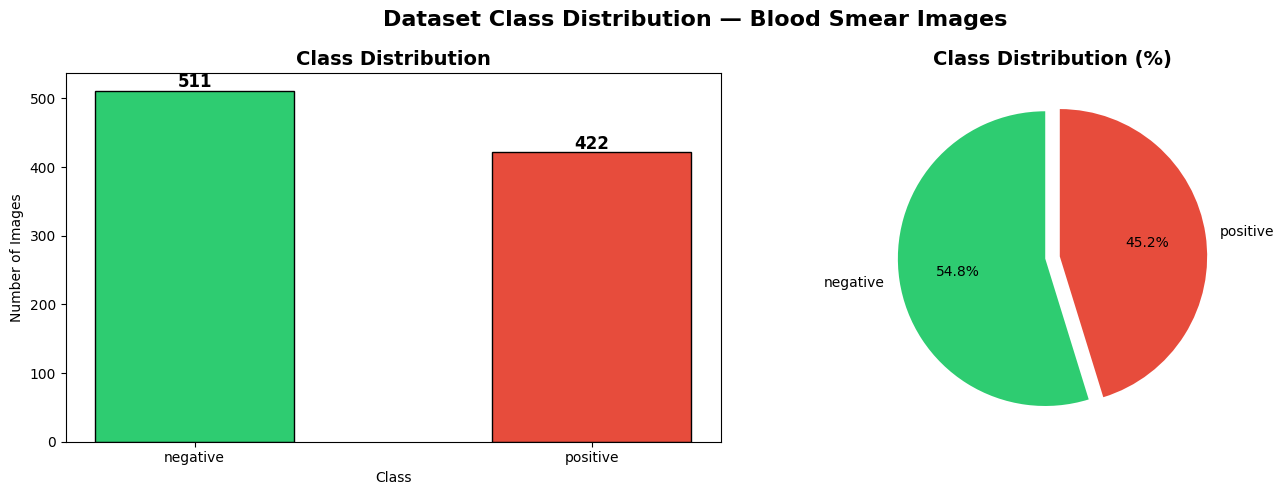

Negative: 511 (54.8%)
Positive: 422 (45.2%)
Imbalance ratio: 1.21:1


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts = df['class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution — Blood Smear Images',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/ml_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Negative: {class_counts['negative']} ({class_counts['negative']/len(df)*100:.1f}%)")
print(f"Positive: {class_counts['positive']} ({class_counts['positive']/len(df)*100:.1f}%)")
print(f"Imbalance ratio: {class_counts['negative']/class_counts['positive']:.2f}:1")

### Observations

The class distribution shows 511 negative images (54.8%) and 422
positive images (45.2%), giving an imbalance ratio of 1.21:1 in
favour of the negative class. This is a mild imbalance that is
unlikely to severely bias a classifier but is still worth addressing
during model training.

In a clinical screening context this imbalance is biologically
plausible — not every patient presenting for screening will have
sickle cell disease. However if left unaddressed, a naive classifier
could achieve 54.8% accuracy simply by predicting every image as
negative, which would be clinically meaningless.

This imbalance will be addressed during model training using the
class_weight='balanced' parameter in both the SVM and Random Forest
classifiers, which automatically adjusts weights inversely
proportional to class frequencies.

## 7. Image Source Distribution

We examine the contribution of each data source to the final
dataset to understand the composition of the training corpus
and any potential domain differences between sources.

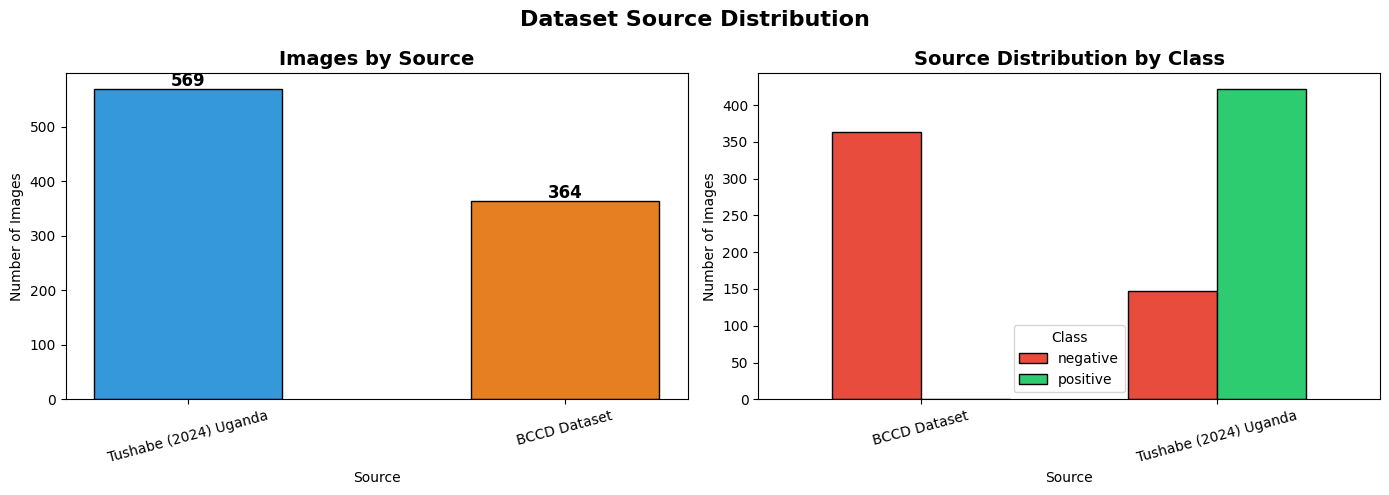


Source by Class breakdown:
source                 class   
BCCD Dataset           negative    364
Tushabe (2024) Uganda  negative    147
                       positive    422
dtype: int64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Source distribution overall
source_counts = df['source'].value_counts()
axes[0].bar(source_counts.index, source_counts.values,
            color=['#3498db', '#e67e22'], edgecolor='black', width=0.5)
axes[0].set_title('Images by Source', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=15)
for i, count in enumerate(source_counts.values):
    axes[0].text(i, count + 5, str(count), ha='center',
                 fontweight='bold', fontsize=12)

# Source distribution by class
source_class = df.groupby(['source', 'class']).size().unstack(fill_value=0)
source_class.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
                  edgecolor='black', width=0.6)
axes[1].set_title('Source Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Class')

plt.suptitle('Dataset Source Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/ml_source_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nSource by Class breakdown:")
print(df.groupby(['source', 'class']).size())

### Observations

The source distribution reveals an important asymmetry in how the
two data sources contribute to each class.

The BCCD Dataset contributes 364 images exclusively to the negative
class. The Tushabe (2024) Uganda dataset contributes all 422 positive
images and 147 of the negative images, giving a total of 569 images
from this source.

This means the negative class is drawn from two visually different
sources — 147 images with the characteristic circular mobile phone
microscope border from Uganda, and 364 images in standard rectangular
format from the BCCD laboratory dataset. This visual inconsistency
within the negative class represents a domain gap that classical ML
models may exploit as a spurious feature rather than learning genuine
biological distinctions between sickle cell and normal blood smears.

This is a documented limitation of the dataset that will be discussed
in the research paper. During model evaluation we will examine whether
the classifier is genuinely learning cell morphology or simply
discriminating between imaging conditions.

## 8. Image Dimension Analysis

We visualise the distribution of image widths and heights across
both classes to confirm the systematic size difference between
the two data sources and justify the resizing step applied during
HOG feature extraction.

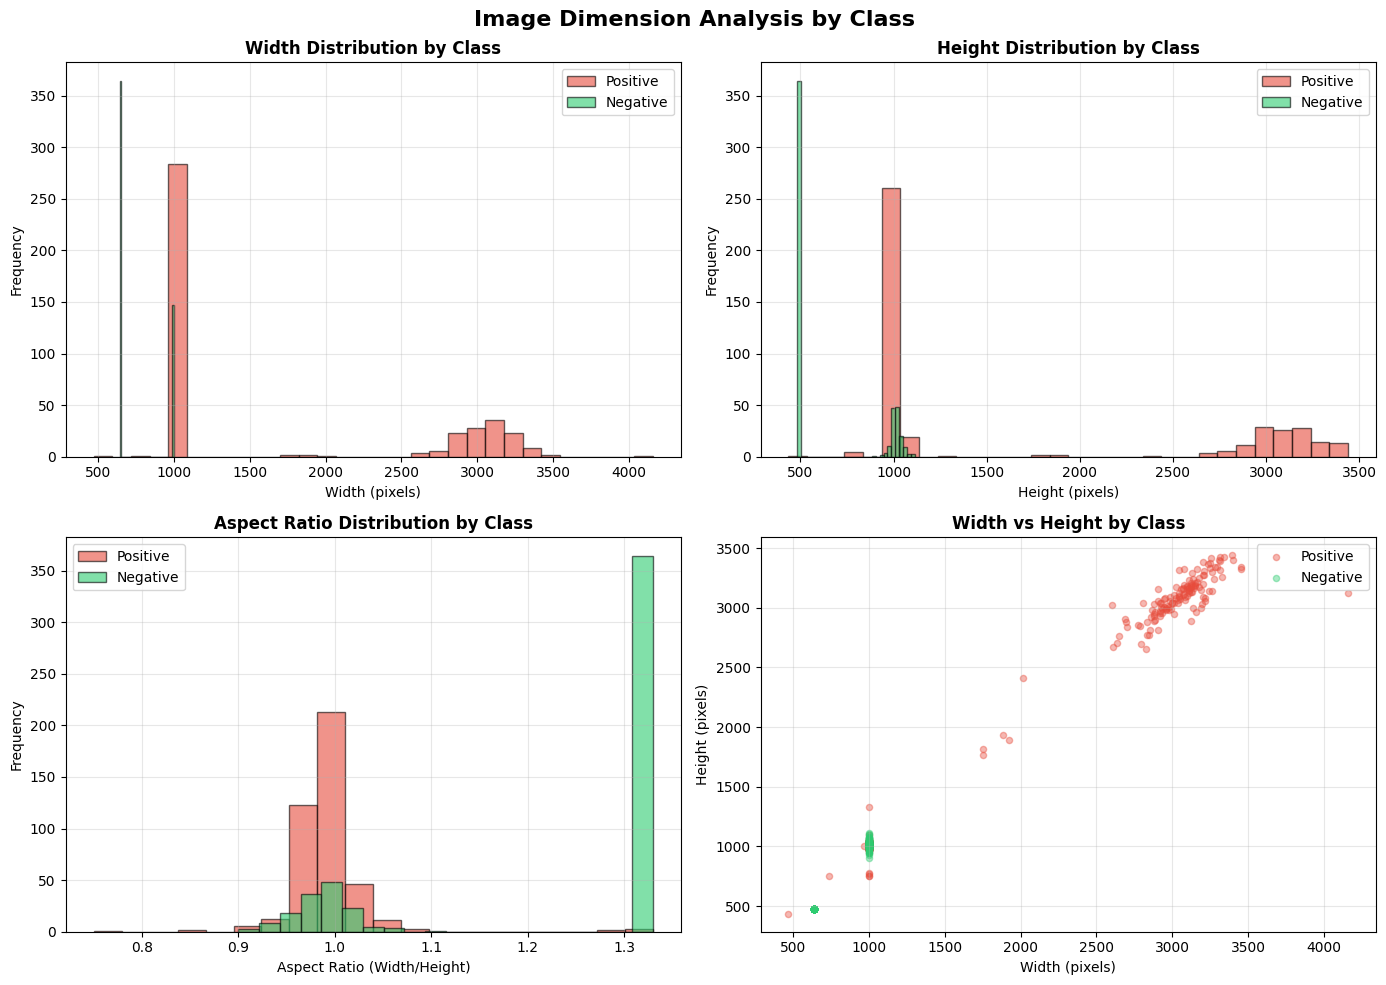

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pos_df = df[df['class'] == 'positive']
neg_df = df[df['class'] == 'negative']

# Width distribution by class
axes[0, 0].hist(pos_df['width'], bins=30, alpha=0.6,
                color='#e74c3c', label='Positive', edgecolor='black')
axes[0, 0].hist(neg_df['width'], bins=30, alpha=0.6,
                color='#2ecc71', label='Negative', edgecolor='black')
axes[0, 0].set_title('Width Distribution by Class', fontweight='bold')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Height distribution by class
axes[0, 1].hist(pos_df['height'], bins=30, alpha=0.6,
                color='#e74c3c', label='Positive', edgecolor='black')
axes[0, 1].hist(neg_df['height'], bins=30, alpha=0.6,
                color='#2ecc71', label='Negative', edgecolor='black')
axes[0, 1].set_title('Height Distribution by Class', fontweight='bold')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Aspect ratio by class
axes[1, 0].hist(pos_df['aspect_ratio'], bins=20, alpha=0.6,
                color='#e74c3c', label='Positive', edgecolor='black')
axes[1, 0].hist(neg_df['aspect_ratio'], bins=20, alpha=0.6,
                color='#2ecc71', label='Negative', edgecolor='black')
axes[1, 0].set_title('Aspect Ratio Distribution by Class', fontweight='bold')
axes[1, 0].set_xlabel('Aspect Ratio (Width/Height)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Scatter plot width vs height
axes[1, 1].scatter(pos_df['width'], pos_df['height'],
                   alpha=0.4, color='#e74c3c', label='Positive', s=20)
axes[1, 1].scatter(neg_df['width'], neg_df['height'],
                   alpha=0.4, color='#2ecc71', label='Negative', s=20)
axes[1, 1].set_title('Width vs Height by Class', fontweight='bold')
axes[1, 1].set_xlabel('Width (pixels)')
axes[1, 1].set_ylabel('Height (pixels)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Image Dimension Analysis by Class',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/ml_dimension_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Observations

The image dimension analysis visually confirms the systematic
differences between the two classes identified in the summary
statistics.

The width and height distribution plots show two distinct clusters.
Negative images are concentrated at lower dimensions, with a large
spike around 640 pixels wide and 480 pixels tall corresponding to
the BCCD dataset images. Positive images show a bimodal distribution
with one cluster around 1000 pixels and another around 3000 pixels,
reflecting the variation in mobile phone camera resolutions used
during Ugandan clinical data collection.

The aspect ratio plot is the most revealing. Negative images show
an extreme spike at 1.33, which is the standard 4:3 aspect ratio
of laboratory cameras. Positive images cluster tightly around 1.0,
the near-square ratio produced by mobile phone cameras placed over
a circular microscope eyepiece. This stark difference in aspect
ratio between the two classes means that a naive classifier could
potentially achieve high accuracy by simply learning aspect ratio
as a discriminating feature rather than learning genuine sickle
cell morphology.

The scatter plot of width versus height confirms the two visually
distinct populations — negative images cluster in the lower left
at small consistent dimensions, while positive images spread across
a wide range of larger dimensions in the upper right.

These findings strongly justify the standardised resizing of all
images to 128x128 pixels during HOG feature extraction, which
eliminates dimension and aspect ratio as potential spurious features
and for

## 9. Sample Image Visualisation

We visually inspect a sample of images from each class to confirm
that the two classes are visually distinguishable and to document
the qualitative differences in imaging conditions between the
Tushabe and BCCD data sources.

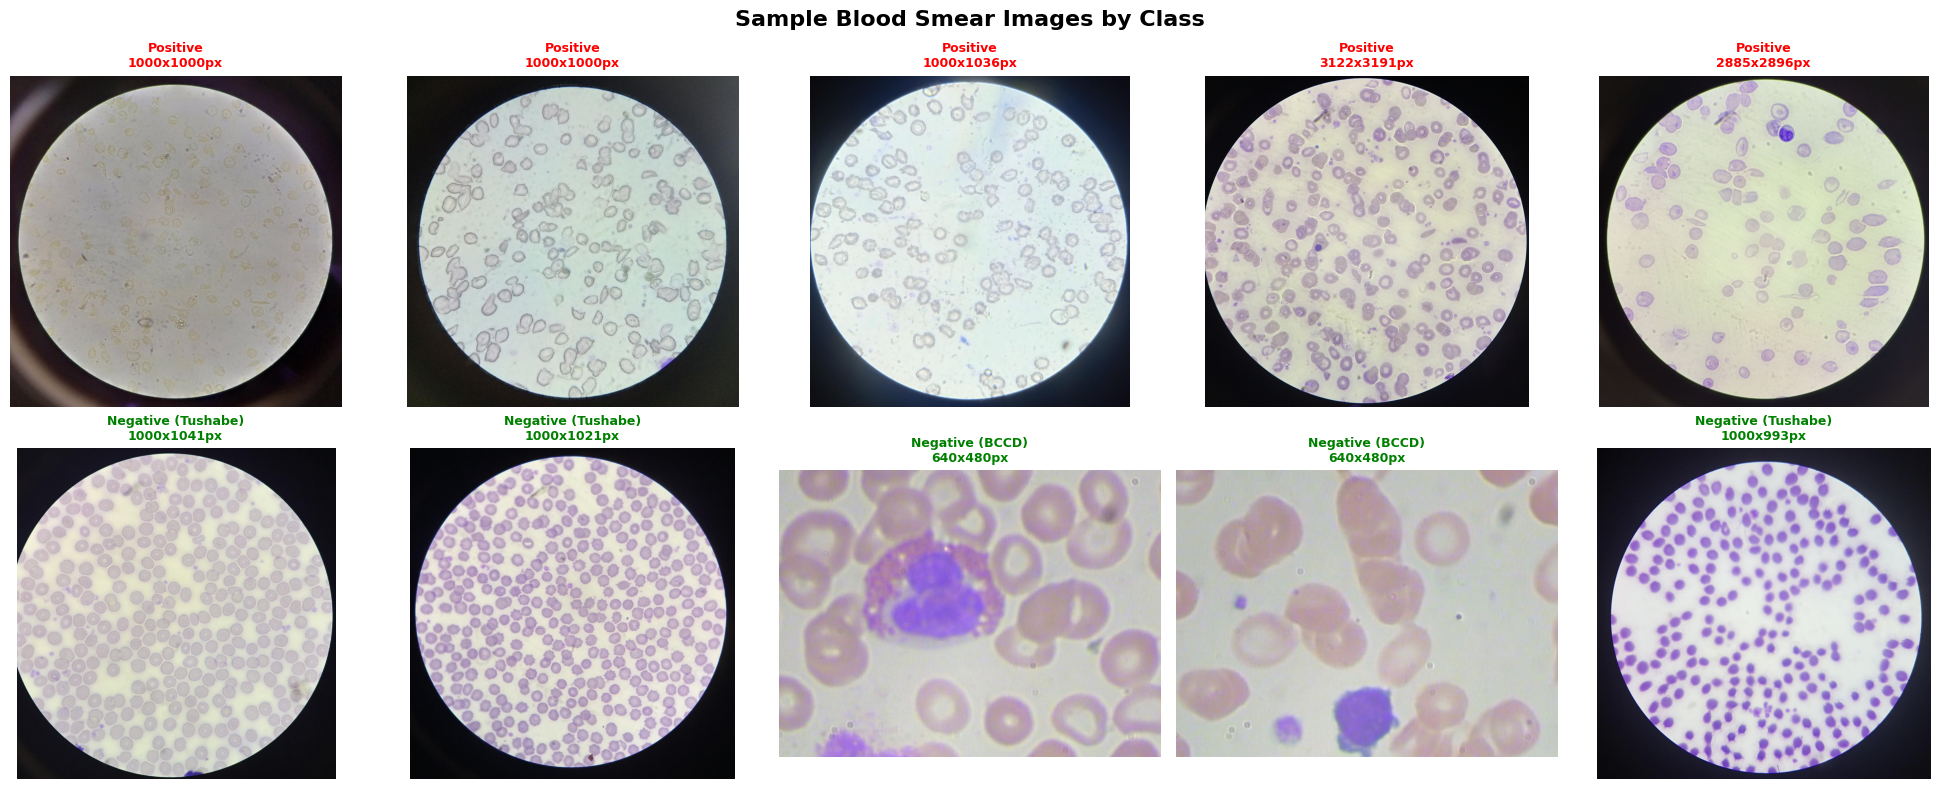

Sample images saved


In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Blood Smear Images by Class',
             fontsize=16, fontweight='bold')

# Sample 5 positive images
pos_samples = pos_df['filename'].sample(5, random_state=42).tolist()
for i, fname in enumerate(pos_samples):
    img = Image.open(os.path.join(POSITIVE_DIR, fname))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Positive\n{img.size[0]}x{img.size[1]}px',
                          fontsize=9, color='red', fontweight='bold')
    axes[0, i].axis('off')

# Sample 5 negative images
neg_samples = neg_df['filename'].sample(5, random_state=42).tolist()
for i, fname in enumerate(neg_samples):
    img = Image.open(os.path.join(NEGATIVE_DIR, fname))
    axes[1, i].imshow(img)
    src = 'BCCD' if 'BloodImage' in fname else 'Tushabe'
    axes[1, i].set_title(f'Negative ({src})\n{img.size[0]}x{img.size[1]}px',
                          fontsize=9, color='green', fontweight='bold')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sickle-cell-detection/figures/ml_sample_images.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sample images saved")

### Observations

The sample image visualisation reveals clear visual differences
between the two classes and confirms the domain gap between the
two negative class data sources.

Positive images in the top row all show the characteristic circular
black border produced by mobile phone cameras placed over a microscope
eyepiece. Within the circular field, elongated crescent-shaped and
irregular red blood cells are visible — the hallmark morphology of
sickle cell disease. Cell density and staining intensity vary across
samples, reflecting the real-world variability of clinical field
collection in Uganda.

Negative images in the bottom row show two visually distinct
subgroups. The first and second images from the left are Tushabe
negative samples — they share the same circular black border and
microscope field of view as the positive images, showing densely
packed normal round red blood cells. The third and fourth images
are BCCD samples — they are rectangular, brighter, and show
individual cells at higher magnification with no circular border.
The fifth image is another Tushabe negative sample.

This visual inspection confirms two important findings. First,
sickle cell positive and normal images are genuinely visually
distinguishable by cell morphology, validating the feasibility
of the classification task. Second, the BCCD negative images look
fundamentally different from all Tushabe images regardless of
class, confirming the domain gap as a real concern that the
classifier must not exploit as a shortcut.

## 10. Data Understanding Summary

We summarise all findings from the data understanding phase and
document the key decisions that inform the feature extraction
and preprocessing steps in subsequent notebooks.

In [12]:
print(" " * 60)
print("DATA UNDERSTANDING SUMMARY")
print("_" * 60)
print(f"""
DATASET COMPOSITION
  Total images:          933
  Positive (sickle):     422  (45.2%)
  Negative (normal):     511  (54.8%)
  Imbalance ratio:       1.21:1 (mild)

DATA SOURCES
  Tushabe (2024) Uganda: 569 images (422 positive + 147 negative)
  BCCD Dataset:          364 images (negative only)

DATA QUALITY
  Missing values:        0 across all columns
  Corrupted images:      0
  Non-RGB images:        0
  All 933 images usable: YES

IMAGE CHARACTERISTICS
  Positive size range:   469 to 4160px (mean 1649x1662px)
  Negative size range:   640 to 1000px (mean 744x634px)
  Positive aspect ratio: ~1.00 (near-square, circular border)
  Negative aspect ratio: ~1.23 (rectangular BCCD format)

KEY DECISIONS FOR NEXT NOTEBOOK
  1. Resize all images to 128x128 before HOG extraction
     to eliminate dimension as a spurious feature
  2. Use class_weight=balanced during model training
     to address the 1.21:1 class imbalance
  3. Document the domain gap between BCCD and Tushabe
     images as a known limitation

DATA UNDERSTANDING COMPLETE — Proceed to 02_feature_extraction.ipynb
""")
print(" " * 60)

                                                            
DATA UNDERSTANDING SUMMARY
____________________________________________________________

DATASET COMPOSITION
  Total images:          933
  Positive (sickle):     422  (45.2%)
  Negative (normal):     511  (54.8%)
  Imbalance ratio:       1.21:1 (mild)

DATA SOURCES
  Tushabe (2024) Uganda: 569 images (422 positive + 147 negative)
  BCCD Dataset:          364 images (negative only)

DATA QUALITY
  Missing values:        0 across all columns
  Corrupted images:      0
  Non-RGB images:        0
  All 933 images usable: YES

IMAGE CHARACTERISTICS
  Positive size range:   469 to 4160px (mean 1649x1662px)
  Negative size range:   640 to 1000px (mean 744x634px)
  Positive aspect ratio: ~1.00 (near-square, circular border)
  Negative aspect ratio: ~1.23 (rectangular BCCD format)

KEY DECISIONS FOR NEXT NOTEBOOK
  1. Resize all images to 128x128 before HOG extraction
     to eliminate dimension as a spurious feature
  2. Use class_w

### Summary

The data understanding phase shows that the dataset is clean and
complete with no missing values across all 933 images. There is a
mild class imbalance of 1.21:1 which will be handled during training.
The biggest challenge identified is the difference in image sizes
and visual appearance between the two data sources. All images will
be resized to 128x128 pixels before HOG feature extraction to ensure
the model learns from cell morphology rather than image dimensions.